In [101]:
# This layer is typically used to build Encoder only models like BERT which excel at tasks like classification, 
# clustering and semantic search.

In [38]:
import numpy as np
import pandas as pd
import torch
import datasets
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [39]:
class EncoderLayer(torch.nn.Module):
    def __init__(self, embed_dim: int, n_heads: int, dim_feedforward: int = 128, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.mha = torch.nn.MultiheadAttention(embed_dim=embed_dim, num_heads=n_heads, batch_first=True, bias=True)
        self.layer_norm1 = torch.nn.LayerNorm(normalized_shape=embed_dim)
        self.layer_norm2 = torch.nn.LayerNorm(normalized_shape=embed_dim)

        # section 5.4
        # apply dropout to output of each sublayer before it is added to sublayer's input
        self.dropout1 = torch.nn.Dropout(p=dropout)
        self.dropout2 = torch.nn.Dropout(p=dropout)
        
        # section 3.3 in paper
        self.position_wise_ff = torch.nn.Sequential(
            torch.nn.Linear(in_features=embed_dim, out_features=dim_feedforward, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=dim_feedforward, out_features=embed_dim, bias=True)
        )
        
    def forward(self, x, src_key_padding_mask=None, src_mask=None):
    # x.shape = (batch_size, seq_len, embed_dim)
    # src_key_padding_mask = (bs, seq_len), True value indicates it should not attend
    # src_mask.shape = (bs, seq_len, seq_len) of dtype torch.bool, True value indicates it shouldn't attend
        ## We obtain contextual embeddings from next line after performing MHA from ordinary embeddings
        attn_output, attn_weights = self.mha(x, x, x, key_padding_mask=src_key_padding_mask, attn_mask=src_mask)
        # dropout and residual connection
        ## we do - ordinary embeddings + contextual embeddings from MHA, before the addition we apply dropout on MHA embeddings
        x  = x + self.dropout1(attn_output)
        ## applying layer norm on new embeddings
        x = self.layer_norm1(x)
        ## applying FFN on new embeddings, the structure of which is mentioned above in torch.nn.Sequential, this is to introduce non-linearity
        projection = self.position_wise_ff(x)
        # dropout and residual connection
        ## again applying dropout and adding to exisiting embeddings
        x = x + self.dropout2(projection)
        # layer norm
        x = self.layer_norm2(x)
        return x ## Final Embeddings

In [40]:
x=torch.rand(2,5,8) ## (batch_size, seq_len, embed_dim)

In [41]:
enc_layer=EncoderLayer(8,2)
enc_layer.forward(x).shape ## Final embeddings, after all computations, the shape of embeddings remain the same as expected

torch.Size([2, 5, 8])

In [42]:
#### Wrapper that contains N different Encoder layers

from copy import deepcopy
class Encoder(torch.nn.Module):
    def __init__(self, encoder_layer, num_layers: int):
        super().__init__()
        layers = []
        for _ in range(num_layers):
            layers.append(deepcopy(encoder_layer))
        self.layers = torch.nn.ModuleList(layers)

    def forward(self, x, src_key_padding_mask=None, src_mask=None):
        for layer in self.layers: 
            ## Input is ordinary token embedding which goes into first encoder layer, output of that is fed to subsequent 
            ## encoder layers. output of one encoder layer is fed as input to next encoder layer.
            x = layer(x, src_key_padding_mask=src_key_padding_mask, src_mask=src_mask)
        return x

In [43]:
encoder=Encoder(enc_layer,6)
encoder.layers
encoder.forward(x).shape

torch.Size([2, 5, 8])

In [44]:
import math
class PositionalEncoding(torch.nn.Module):
    # source: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial6/Transformers_and_MHAttention.html#Positional-encoding
    def __init__(self, embed_dim, max_len=256):
        super().__init__()
        # create a matrix of [seq_len, hidden_dim] representing positional encoding for each token in sequence
        pe = torch.zeros(max_len, embed_dim) ## max_len is the number of tokens, each token embedding has embed_dim no. of dimensions
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # (max_len, 1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [45]:
pos_enc=PositionalEncoding(8)
pos_enc(enc_layer.forward(x)).shape

torch.Size([2, 5, 8])

In [47]:
class TextClassifier(torch.nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, num_classes: int, encoder: torch.nn.Module, max_len):
        super().__init__()
        self.positional_encoding = PositionalEncoding(embed_dim=embed_dim, max_len=max_len)
        self.embedding = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=0)
        self.encoder = encoder
        self.fc1 = torch.nn.Linear(in_features=embed_dim, out_features=128)
        self.relu = torch.nn.ReLU()
        self.final = torch.nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, input_ids: torch.Tensor, src_key_padding_mask=None, **kwargs):
        # inputs: (bs, seq_len)
        # embeddings: (bs, seq_len, embed_dim)
        embeddings = self.get_embeddings(input_ids) ## Retrieve positional encodings
        attn = self.encoder(embeddings, src_key_padding_mask=src_key_padding_mask) ## Applying entire encoder block on embedded data
                                    
        # take the first token's embeddings i.e. embeddings of CLS token
        # cls_token_embeddings: (bs, embed_dim)
        cls_token_embeddings = attn[:, 0, :] ## cls token provides a summarized view of the entire sequence
        return self.final(self.relu(self.fc1(cls_token_embeddings)))
    
    def get_embeddings(self, input_ids):
        return self.positional_encoding(self.embedding(input_ids))

In [48]:
original_tokenizer=AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

news_ds=datasets.load_dataset("SetFit/bbc-news", split="train")
# train a new tokenizer with limited vocab size for demo

# To keep things small, I created a new tokenizer with same config as original_tokenizer but with vocabulary size of just 1000. 
# Original tokenizer has vocab size of 30,522 which results in large amount of data in Embedding layer. For this purpose 
# vocab size of 1000 is just fine and we can train our models quickly in CPU as well.

tokenizer = original_tokenizer.train_new_from_iterator(news_ds['text'], vocab_size=500)

In [49]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True)

ds=news_ds.map(tokenize, batched=True).select_columns(['label', 'input_ids', 'text']).train_test_split() 


class_id_to_class = {
    0: "tech",
    1: "business",
    2: "sports",
    3: "entertainment",
    4: "politics",
}
num_classes = len(class_id_to_class)

Map:   0%|          | 0/1225 [00:00<?, ? examples/s]

In [50]:
embed_dim = 128
n_head = 8
dim_feedforward = 256
num_layers = 2
vocab_size = tokenizer.vocab_size
max_length = tokenizer.model_max_length



# Pytorch
## Single encoder block
torch_encoder_layer = torch.nn.TransformerEncoderLayer(
    d_model=embed_dim, ## Number of dimensions of each token embedding
    nhead=n_head, ## Number of heads in MHA
    dim_feedforward=dim_feedforward, ## 
    dropout=0.1,
    batch_first=True,
    norm_first=False,
)
## num_layers encoder blocks creating an enocoder network
torch_encoder = torch.nn.TransformerEncoder(
    encoder_layer=torch_encoder_layer, num_layers=num_layers
)

torch_classifier = TextClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_classes=num_classes,
    encoder=torch_encoder, ## Encder Network
    max_len=max_length,
)




## Custom 
# my single encoder block
my_encoder_layer = EncoderLayer(
    embed_dim=embed_dim, n_heads=n_head, dim_feedforward=dim_feedforward, dropout=0.1
)
## my encoder network
my_encoder = Encoder(encoder_layer=my_encoder_layer, num_layers=num_layers)

my_classifier = TextClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_classes=num_classes,
    encoder=my_encoder,  ## Encder Network
    max_len=max_length,
)


In [51]:
def get_model_param_count(model):
    return sum(t.numel() for t in model.parameters())


print(f"My classifier params: {get_model_param_count(my_classifier):,}")
print(f"Torch classifier params: {get_model_param_count(torch_classifier):,}")

My classifier params: 346,117
Torch classifier params: 346,117


In [84]:
from torch.utils.data import DataLoader
import time

def collate_fn(batch):
    labels = []
    input_ids = []
    for row in batch:
        labels.append(row['label'])
        input_ids.append(torch.LongTensor(row['input_ids']))

    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=0)
    labels = torch.LongTensor(labels)
    input_ids = torch.Tensor(input_ids)
    return {"labels": labels, "input_ids": input_ids}

train_dl = DataLoader(ds['train'], shuffle=True, batch_size=32, collate_fn=collate_fn)
test_dl = DataLoader(ds['test'], shuffle=False, batch_size=32, collate_fn=collate_fn)

In [86]:
def train(model: torch.nn.Module, train_dl, val_dl, epochs):
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3)  ## Initializing optimizer
    loss_fn = torch.nn.CrossEntropyLoss() ## Initializing loss function
    losses = []
    train_start = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()
        train_loss = 0.0
        model.train()
        for batch in train_dl:
            optim.zero_grad()
            logits = model(**batch)  ## [bs, num_classes]
            print(logits.shape) 
            if logits.dim()==3:
                logits=logits[:, -1, :]
            else:
                logits=logits
            loss = loss_fn(logits, batch['labels']) ## single loss value as a tensor, hence loss.item() required
            loss.backward()
            optim.step()
            train_loss += loss.item() * batch['labels'].size(0) ## loss.item() was the mean loss per batch, we multiply by the batch size to get total loss in a batch of 32 samples

        train_loss /= len(train_dl.dataset) ## We finally find mean loss per sample by dividing total loss by total number of training samples

        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0
        with torch.no_grad():
            for batch in val_dl:
                logits = model(**batch)
                if logits.dim()==3:
                    logits=logits[:, -1, :]
                else:
                    logits=logits
                loss = loss_fn(logits, batch['labels'])
                val_loss += loss.item() * batch['labels'].size(0)
                val_accuracy += (logits.argmax(dim=1) == batch['labels']).sum()
                

        val_loss /= len(val_dl.dataset)
        val_accuracy /= len(val_dl.dataset)
        log_steps = max(1, int(0.2 * epochs))

        losses.append((train_loss, val_loss)) ## for each epoch
        if epoch % log_steps == 0 or epoch == epochs - 1:  ## [either a multiple of 2 (0,2,4,6,8) or 9] [0,2,4,6,8,9]
            epoch_duartion = time.time() - epoch_start
            print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}. Epoch Duration: {epoch_duartion:.1f} seconds')   ## prints 0+1, 2+1,.....

    train_duration = time.time() - train_start
    print(f"Training finished. Took {train_duration:.1f} seconds")

    return losses

In [87]:
def get_model_param_count(model):
    return sum(t.numel() for t in model.parameters())

print(f" My classifier params: {get_model_param_count(my_classifier):,}")
print(f"Torch classifier params: {get_model_param_count(torch_classifier):,}")

 My classifier params: 346,117
Torch classifier params: 346,117


In [88]:
torch_losses=train(torch_classifier,train_dl,test_dl,epochs=1)
my_losses=train(my_classifier,train_dl,test_dl,epochs=1)

torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([22, 5])
Epoch 1/1, Training Loss: 1.6178, Validation Loss: 1.5833, Validation Accuracy: 0.2182. Epoch Duration: 166.9 seconds
Training finished. Took 166.9 seconds
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torch.Size([32, 5])
torc

In [89]:
def predict(model: torch.nn.Module, val_dl):
    output_dfs=[]
    with torch.no_grad():
        for batch in val_dl:
            class_probs=torch.softmax(model(**batch),dim=1).numpy() ## Matrix of shape [batch_size, num_classes] contains the prob of each class for all 32 samples
            pred_classes=class_probs.argmax(axis=1) ## array of length 32 with the class index of the class with highest probability
#                 print(class_probs.shape[-1])
            col_names=[f"class_{i}_prob" for i in range(class_probs.shape[-1])]  ## class_probs.shape [32,5]
            df = pd.DataFrame(class_probs, columns=col_names)
            df['pred_class'] = pred_classes
            df['pred_class_name'] = df['pred_class'].map(class_id_to_class)
            output_dfs.append(df)

    return pd.concat(output_dfs)

In [90]:
my_preds_df = predict(my_classifier,test_dl)
my_preds_df['model'] = 'My Model'
my_preds_df['actual_class'] = ds['test']['label']

torch_preds_df = predict(torch_classifier,test_dl)
torch_preds_df['model'] = 'Torch Model'
torch_preds_df['actual_class'] = ds['test']['label']

In [91]:
torch_preds_df

,class_0_prob,class_1_prob,class_2_prob,class_3_prob,class_4_prob,pred_class,pred_class_name,model,actual_class
0,0.227514,0.194154,0.168149,0.158871,0.251311,4,politics,Torch Model,4
1,0.225393,0.203925,0.165647,0.172621,0.232415,4,politics,Torch Model,1
2,0.235992,0.188424,0.183736,0.165815,0.226033,0,tech,Torch Model,1
3,0.231828,0.203349,0.176137,0.165342,0.223344,0,tech,Torch Model,1
4,0.220311,0.164082,0.208180,0.170138,0.237289,4,politics,Torch Model,2
...,...,...,...,...,...,...,...,...,...
14,0.219132,0.198198,0.174869,0.170610,0.237191,4,politics,Torch Model,1
15,0.223686,0.168766,0.191975,0.169001,0.246572,4,politics,Torch Model,3
16,0.225773,0.190027,0.176804,0.169746,0.237650,4,politics,Torch Model,1
17,0.221680,0.176432,0.189987,0.168172,0.243729,4,politics,Torch Model,4


In [92]:
from sklearn.metrics import classification_report

print("My Classifier")
print(classification_report(my_preds_df['actual_class'], my_preds_df['pred_class']))

print("Torch Classifier")
print(classification_report(torch_preds_df['actual_class'], torch_preds_df['pred_class']))

My Classifier
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        48
           1       0.29      1.00      0.45        70
           2       0.74      0.67      0.71        73
           3       0.00      0.00      0.00        55
           4       0.00      0.00      0.00        61

    accuracy                           0.39       307
   macro avg       0.21      0.33      0.23       307
weighted avg       0.24      0.39      0.27       307

Torch Classifier
              precision    recall  f1-score   support

           0       0.22      0.31      0.26        48
           1       0.00      0.00      0.00        70
           2       0.00      0.00      0.00        73
           3       0.00      0.00      0.00        55
           4       0.22      0.85      0.35        61

    accuracy                           0.22       307
   macro avg       0.09      0.23      0.12       307
weighted avg       0.08      0.22      0.11   

C:\Users\Amrita\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Amrita\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Amrita\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Amrita\anaconda3\lib\site-pa

In [93]:
def get_losses_as_df(losses_name_pairs):
    dfs = []
    for model_name, losses in losses_name_pairs:
        df = pd.DataFrame(losses, columns=['train_loss', 'test_loss']).reset_index().rename(columns={"index": "epoch"})
        df['model'] = model_name
        dfs.append(df)
    return pd.concat(dfs)

def plot_losses(loss_df):
    df = loss_df.melt(id_vars=['model', 'epoch'], var_name='metric')
    return ggplot(df, aes('epoch', 'value', color='metric')) + geom_line() + geom_point(size=1.5) + facet_grid('model') + labs(title="Train and Validation loss")


loss_df=get_losses_as_df([("My_Model", my_losses), ("Torch", torch_losses)])

In [94]:
loss_df_my=loss_df[loss_df['model']=='My_Model']
loss_df_torch=loss_df[loss_df['model']=='Torch']

In [99]:
loss_df_my

,epoch,train_loss,test_loss,model
0,0,1.620957,1.569389,My_Model


In [100]:
loss_df_torch

,epoch,train_loss,test_loss,model
0,0,1.617842,1.583319,Torch


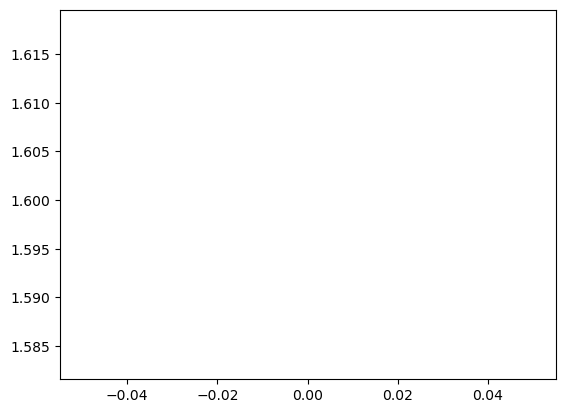

In [96]:
plt.plot(loss_df_torch['epoch'],loss_df_torch['train_loss'],label='Train Loss') 
plt.plot(loss_df_torch['epoch'],loss_df_torch['test_loss'],label='Test Loss')

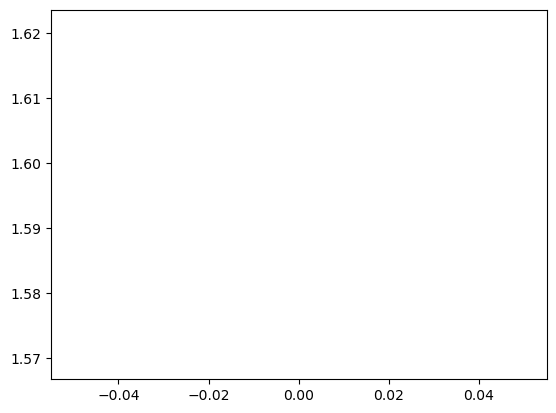

In [97]:
plt.plot(loss_df_my['epoch'],loss_df_my['train_loss'],label='Train Loss') 
plt.plot(loss_df_my['epoch'],loss_df_my['test_loss'],label='Test Loss')